In [127]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from urllib.request import urlopen

## 1) Случайный массив и операции

- shape / dtype  
- индексация и срезы  
- поэлементные операции (векторизация)  
- агрегаты (min/max/mean/sum, axis)  
- маска и замена по маске  
- reshape / transpose  
- сортировка  
- матричное умножение `@`

In [128]:
np.random.seed(42)

A = np.random.randint(0, 100, size=(5, 6))
print("A:\n", A)
print("shape:", A.shape)
print("dtype:", A.dtype)

A:
 [[51 92 14 71 60 20]
 [82 86 74 74 87 99]
 [23  2 21 52  1 87]
 [29 37  1 63 59 20]
 [32 75 57 21 88 48]]
shape: (5, 6)
dtype: int32


In [129]:
print("\nA[0, 0] =", A[0, 0])
print("A[0] =", A[0])
print("A[:, 2] =", A[:, 2])
print("A[1:4, 2:5]:\n", A[1:4, 2:5])


A[0, 0] = 51
A[0] = [51 92 14 71 60 20]
A[:, 2] = [14 74 21  1 57]
A[1:4, 2:5]:
 [[74 74 87]
 [21 52  1]
 [ 1 63 59]]


In [130]:
B = A * 2 + 1
print("\nB = A*2+1:\n", B)


B = A*2+1:
 [[103 185  29 143 121  41]
 [165 173 149 149 175 199]
 [ 47   5  43 105   3 175]
 [ 59  75   3 127 119  41]
 [ 65 151 115  43 177  97]]


In [131]:
print("\nmin:", A.min(), "max:", A.max(), "mean:", A.mean(), "sum:", A.sum())
print("sum по строкам (axis=1):", A.sum(axis=1))
print("mean по столбцам (axis=0):", A.mean(axis=0))


min: 1 max: 99 mean: 50.86666666666667 sum: 1526
sum по строкам (axis=1): [308 502 186 209 321]
mean по столбцам (axis=0): [43.4 58.4 33.4 56.2 59.  54.8]


In [132]:
mask = A > 50
print("\nmask (A > 50):\n", mask)
print("Элементы A>50:", A[mask])
A2 = A.copy()
A2[A2 < 30] = 0
print("\nA2 (всё <30 заменили на 0):\n", A2)


mask (A > 50):
 [[ True  True False  True  True False]
 [ True  True  True  True  True  True]
 [False False False  True False  True]
 [False False False  True  True False]
 [False  True  True False  True False]]
Элементы A>50: [51 92 71 60 82 86 74 74 87 99 52 87 63 59 75 57 88]

A2 (всё <30 заменили на 0):
 [[51 92  0 71 60  0]
 [82 86 74 74 87 99]
 [ 0  0  0 52  0 87]
 [ 0 37  0 63 59  0]
 [32 75 57  0 88 48]]


In [133]:
v = np.random.randn(12)
M = v.reshape(3, 4)
print("\nM (3x4):\n", M)
print("M.T:\n", M.T)


M (3x4):
 [[-2.43910582  0.60344123 -0.25104397 -0.16386712]
 [-1.47632969  1.48698096 -0.02445518  0.35555132]
 [ 0.41701111  0.83246186 -0.29339915 -0.02983857]]
M.T:
 [[-2.43910582 -1.47632969  0.41701111]
 [ 0.60344123  1.48698096  0.83246186]
 [-0.25104397 -0.02445518 -0.29339915]
 [-0.16386712  0.35555132 -0.02983857]]


In [134]:
print("\nsort по строкам:\n", np.sort(A, axis=1))
print("argsort первой строки:", np.argsort(A[0]))


sort по строкам:
 [[14 20 51 60 71 92]
 [74 74 82 86 87 99]
 [ 1  2 21 23 52 87]
 [ 1 20 29 37 59 63]
 [21 32 48 57 75 88]]
argsort первой строки: [2 5 0 4 3 1]


In [135]:
X = np.random.randn(3, 2)
Y = np.random.randn(2, 4)
Z = X @ Y
print("\nX shape:", X.shape, "Y shape:", Y.shape, "Z shape:", Z.shape)


X shape: (3, 2) Y shape: (2, 4) Z shape: (3, 4)


## 2) OpenCV: выделение объектов на изображении

План:
1) скачать изображение  
2) перевести в серый  
3) сгладить (GaussianBlur)  
4) бинаризация (порог + Otsu)  
5) найти контуры  
6) обвести каждый объект прямоугольником

In [ ]:
def imshow_rgb(title, img_bgr):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(7, 5))
    plt.title(title)
    plt.axis("off")
    plt.imshow(img_rgb)
    plt.show()

Image shape: (209, 241, 3)


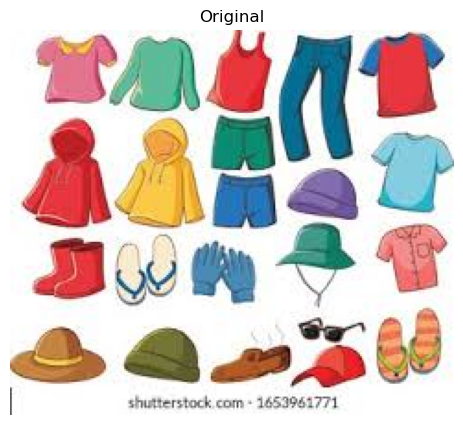

In [ ]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSJlC-lS7tdp6l-zpdVGHD4I_yi_V2DhdRm5A&s"

resp = urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

print("Размеры изображения:", img.shape)
imshow_rgb("изображение", img)

In [138]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

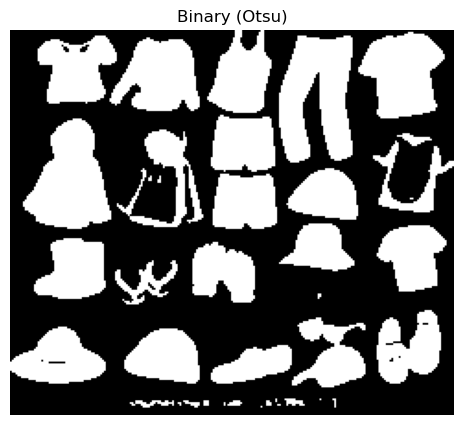

Contours found: 39


In [ ]:
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.figure(figsize=(7, 5))
plt.axis("off")
plt.imshow(binary, cmap="gray")
plt.show()

contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print("контуров найдено:", len(contours))

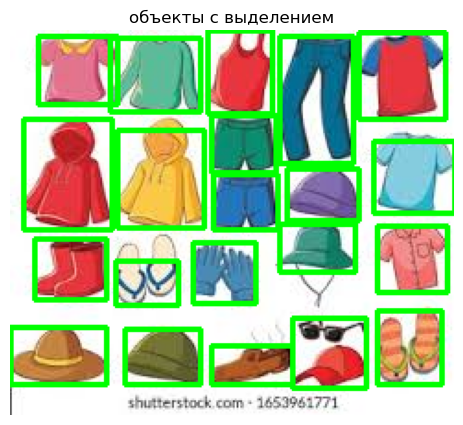

In [140]:
vis = img.copy()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 100:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)

imshow_rgb("объекты с выделением",vis)

## 3) Реализация rectangle "с нуля"

Смысл: изображение — это NumPy-массив.  
Чтобы нарисовать прямоугольник, мы просто присваиваем цвет пикселям по срезам (верх/низ/лево/право).

In [ ]:
def rectangle_numpy(img, pt1, pt2, color=(0, 0, 255), thickness=2):

    out = img.copy()

    x1, y1 = pt1
    x2, y2 = pt2

    x1, x2 = sorted([x1, x2])
    y1, y2 = sorted([y1, y2])

    H, W = out.shape[:2]
    t = max(1, int(thickness))

    x1 = max(0, min(W - 1, x1))
    x2 = max(0, min(W - 1, x2))
    y1 = max(0, min(H - 1, y1))
    y2 = max(0, min(H - 1, y2))

    out[y1:y1+t, x1:x2+1] = color
    out[y2-t+1:y2+1, x1:x2+1] = color
    out[y1:y2+1, x1:x1+t] = color
    out[y1:y2+1, x2-t+1:x2+1] = color

    return out

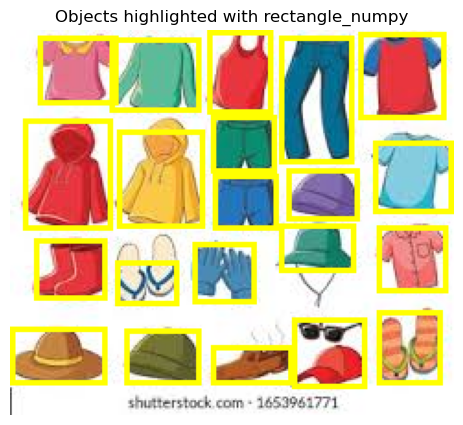

In [ ]:
vis2 = img.copy()
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 100:
        continue
    x, y, w, h = cv2.boundingRect(cnt)
    vis2 = rectangle_numpy(vis2, (x, y), (x + w, y + h), color=(0, 255, 255), thickness=3)

imshow_rgb("Объекты с выделением (свой прямоугольник)", vis2)